# 05 — ¿Cuánto vale ser anfitrión del Mundial?

**Proyecto:** El Sexto Partido — México en el Mundial 2026

**Pregunta concreta:** ¿Cuánto sube la probabilidad de avanzar una vez que controlamos por el nivel de la selección (ELO)? Este es **el hallazgo central del proyecto**.

**Modelo:** regresión logística.

$$\log\left(\frac{P(\text{avanza})}{1 - P(\text{avanza})}\right) = \alpha + \beta \cdot \text{elo} + \gamma \cdot \text{es\_anfitrion}$$

El coeficiente $\gamma$ (con su intervalo de confianza) nos dice **el efecto puro de ser anfitrión**, una vez que ya consideramos que el equipo es bueno o malo. Si $\gamma > 0$ y su IC no cruza 0, ser anfitrión sube la probabilidad de manera estadísticamente significativa.

**Dos modelos paralelos:**
1. `pasa_de_grupos` → relevante para selecciones de nivel medio.
2. `llega_a_cuartos` (≡ sexto partido en formato 2026) → el corazón de la historia de México.

## 1. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

PROCESSED = ROOT / 'data' / 'processed'
OUTPUTS = ROOT / 'outputs'

VERDE_MX = '#006847'
GRIS = '#999999'
ROJO = '#CE1126'
AZUL = '#1f77b4'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

wc = pd.read_csv(PROCESSED / 'world_cup_matches.csv')
wc['date'] = pd.to_datetime(wc['date'])
timeline = pd.read_parquet(PROCESSED / 'elo_timeline.parquet')
timeline['date'] = pd.to_datetime(timeline['date'])

## 2. Construir el dataset (selección × edición)

Una fila por **(selección, edición de Mundial)**. Columnas:
- `elo_pre`: ELO de la selección justo antes de la edición.
- `es_anfitrion`: 1 si fue anfitriona ese año.
- `pasa_grupos`: 1 si llegó a octavos o más allá.
- `llega_cuartos`: 1 si llegó a cuartos o más allá.

Solo usamos mundiales 1986-2022 (donde la inferencia de fase es confiable y el formato moderno aplica).

In [2]:
ANFITRIONES = {
    1986: ['Mexico'], 1990: ['Italy'], 1994: ['United States'],
    1998: ['France'], 2002: ['South Korea', 'Japan'],
    2006: ['Germany'], 2010: ['South Africa'], 2014: ['Brazil'],
    2018: ['Russia'], 2022: ['Qatar'],
}

PHASE_VAL = {'Group': 1, 'Round of 16': 2, 'Quarter-final': 3,
             'Semi-final': 4, 'Third-place': 5, 'Final': 6, 'Other': 0}

ediciones_modernas = [1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]
wc_modern = wc[wc['edition'].isin(ediciones_modernas)].copy()
wc_modern['phase_val'] = wc_modern['phase'].map(PHASE_VAL)

# Mejor fase de cada equipo por edición
filas = []
for ed in ediciones_modernas:
    sub = wc_modern[wc_modern['edition'] == ed]
    teams = set(sub['home_team']) | set(sub['away_team'])
    inicio = sub['date'].min()
    for t in teams:
        # mejor fase en esta edición
        partidos_t = sub[(sub['home_team'] == t) | (sub['away_team'] == t)]
        best = partidos_t['phase_val'].max()
        # ELO pre-mundial
        prev = timeline[(timeline['team'] == t) & (timeline['date'] < inicio)].sort_values('date')
        elo_pre = prev['rating'].iloc[-1] if len(prev) else np.nan
        # anfitrión?
        es_anf = int(t in ANFITRIONES.get(ed, []))
        filas.append({
            'edition': ed, 'team': t, 'elo_pre': elo_pre,
            'es_anfitrion': es_anf,
            'pasa_grupos': int(best >= 2),
            'llega_cuartos': int(best >= 3),
            'best_phase': int(best),
        })

ds = pd.DataFrame(filas).dropna(subset=['elo_pre']).reset_index(drop=True)
print(f'Filas dataset: {len(ds)} (selección × edición)')
print(f'Anfitrionas: {ds["es_anfitrion"].sum()}')
ds.head()

Filas dataset: 296 (selección × edición)
Anfitrionas: 11


,edition,team,elo_pre,es_anfitrion,pasa_grupos,llega_cuartos,best_phase
0,1986,Brazil,1741.862241,0,1,1,3
1,1986,Denmark,1601.861070,0,1,0,2
2,1986,Algeria,1637.597818,0,0,0,1
3,1986,Poland,1673.770001,0,1,0,2
4,1986,Scotland,1651.615812,0,0,0,1


## 3. EDA: ¿cómo es el ELO de anfitriones vs resto?

Antes del modelo, miremos los datos crudos. Si los anfitriones son sistemáticamente más fuertes que el promedio, parte de su "ventaja" en avance es ELO, no localía.

/tmp/ipykernel_13936/3138715193.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No anfitrión', 'Anfitrión'])


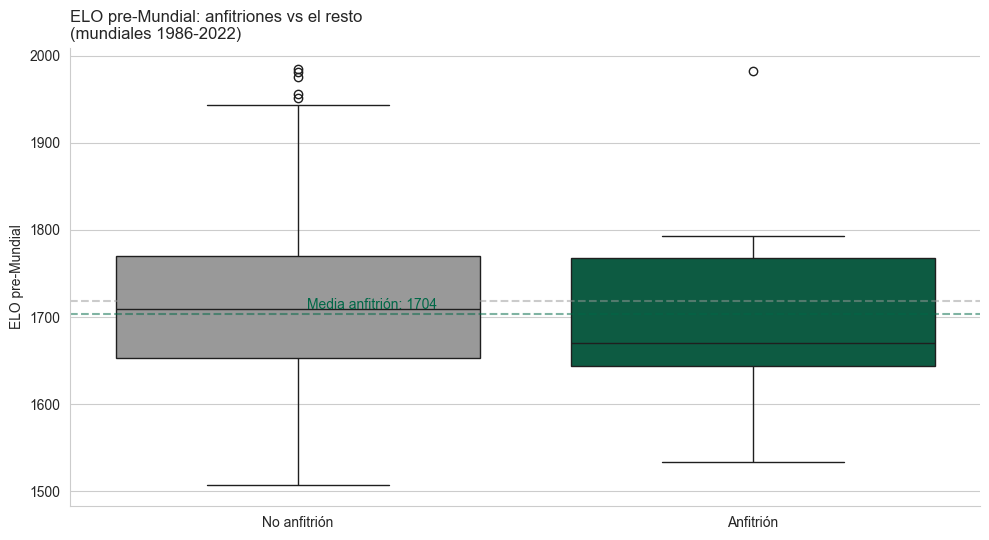


Diferencia de ELO: anfitrión − no anfitrión = -14 puntos


In [3]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=ds, x='es_anfitrion', y='elo_pre', ax=ax,
            palette={0: GRIS, 1: VERDE_MX}, hue='es_anfitrion', legend=False)
ax.set_xticklabels(['No anfitrión', 'Anfitrión'])
ax.set_xlabel('')
ax.set_ylabel('ELO pre-Mundial')
ax.set_title('ELO pre-Mundial: anfitriones vs el resto\n(mundiales 1986-2022)', loc='left')

mu_no = ds[ds['es_anfitrion'] == 0]['elo_pre'].mean()
mu_si = ds[ds['es_anfitrion'] == 1]['elo_pre'].mean()
ax.axhline(mu_no, color=GRIS, linestyle='--', alpha=0.5)
ax.axhline(mu_si, color=VERDE_MX, linestyle='--', alpha=0.5)
ax.text(0.02, mu_no + 5, f'Media no-anfitrión: {mu_no:.0f}', color=GRIS, fontsize=10)
ax.text(0.02, mu_si + 5, f'Media anfitrión: {mu_si:.0f}', color=VERDE_MX, fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUTS / 'host_01_elo_anfitrion_vs_resto.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nDiferencia de ELO: anfitrión − no anfitrión = {mu_si - mu_no:+.0f} puntos')

**Confirmamos el problema de confusión:** los anfitriones tienen ELO promedio más alto que el resto. Si no controlamos por eso, sobreestimaríamos el efecto de ser anfitrión.

## 4. Modelo 1: ¿pasa de grupos?

Regresión logística con ELO como control.

In [4]:
# Centramos ELO para que el intercepto sea interpretable
ds['elo_c'] = ds['elo_pre'] - 1750  # ~ELO medio de un seleccionado mundialista

X = sm.add_constant(ds[['elo_c', 'es_anfitrion']])
y_grupos = ds['pasa_grupos']

logit_grupos = sm.Logit(y_grupos, X).fit(disp=False)
print(logit_grupos.summary())

                           Logit Regression Results                           
Dep. Variable:            pasa_grupos   No. Observations:                  296
Model:                          Logit   Df Residuals:                      293
Method:                           MLE   Df Model:                            2
Date:                Fri, 15 May 2026   Pseudo R-squ.:                 0.07886
Time:                        23:15:34   Log-Likelihood:                -188.10
converged:                       True   LL-Null:                       -204.20
Covariance Type:            nonrobust   LLR p-value:                 1.016e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.3840      0.138      2.778      0.005       0.113       0.655
elo_c            0.0075      0.002      4.916      0.000       0.005       0.010
es_anfitrion     1.6759      0.825      2.03

In [5]:
def resumen_coef(modelo, nombre):
    coef = modelo.params['es_anfitrion']
    se = modelo.bse['es_anfitrion']
    ci = modelo.conf_int().loc['es_anfitrion']
    p = modelo.pvalues['es_anfitrion']
    odds_ratio = np.exp(coef)
    or_low, or_high = np.exp(ci[0]), np.exp(ci[1])
    print(f'=== {nombre} ===')
    print(f'  Coef anfitrión: {coef:+.3f}  (SE = {se:.3f})')
    print(f'  Odds ratio:     {odds_ratio:.2f}  IC95% [{or_low:.2f}, {or_high:.2f}]')
    print(f'  p-valor:        {p:.4f}')
    return odds_ratio, or_low, or_high

or_g, ci_g_lo, ci_g_hi = resumen_coef(logit_grupos, 'PASA DE GRUPOS')

=== PASA DE GRUPOS ===
  Coef anfitrión: +1.676  (SE = 0.825)
  Odds ratio:     5.34  IC95% [1.06, 26.91]
  p-valor:        0.0421


## 5. Modelo 2: ¿llega a cuartos (sexto partido)?

In [6]:
y_cuartos = ds['llega_cuartos']
logit_cuartos = sm.Logit(y_cuartos, X).fit(disp=False)
print(logit_cuartos.summary())
print()
or_c, ci_c_lo, ci_c_hi = resumen_coef(logit_cuartos, 'LLEGA A CUARTOS')

                           Logit Regression Results                           
Dep. Variable:          llega_cuartos   No. Observations:                  296
Model:                          Logit   Df Residuals:                      293
Method:                           MLE   Df Model:                            2
Date:                Fri, 15 May 2026   Pseudo R-squ.:                  0.1238
Time:                        23:15:34   Log-Likelihood:                -151.35
converged:                       True   LL-Null:                       -172.72
Covariance Type:            nonrobust   LLR p-value:                 5.206e-10
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.9142      0.145     -6.289      0.000      -1.199      -0.629
elo_c            0.0091      0.002      5.558      0.000       0.006       0.012
es_anfitrion     2.0571      0.704      2.92

## 6. Forest plot: el hallazgo del proyecto

Los coeficientes en odds ratio (OR) son más interpretables que en log-odds. Un OR de 2 significa: ser anfitrión duplica las odds de avanzar (controlando por nivel).

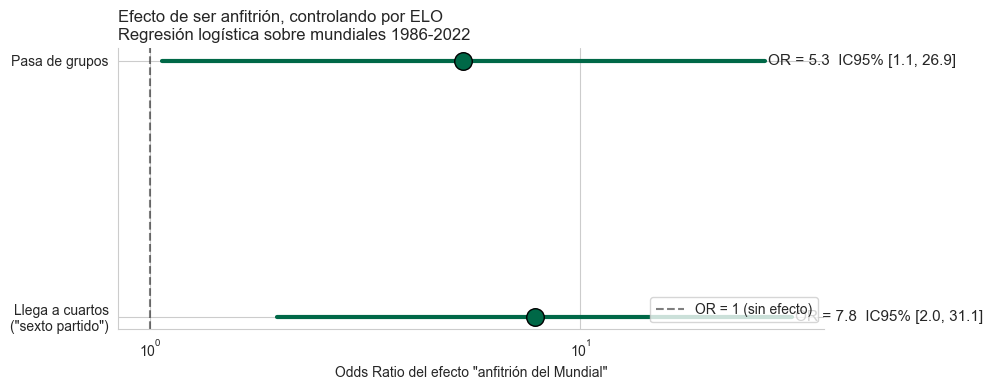

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
y_pos = [1, 0]
ors = [or_g, or_c]
los = [ci_g_lo, ci_c_lo]
his = [ci_g_hi, ci_c_hi]
labels = ['Pasa de grupos', 'Llega a cuartos\n("sexto partido")']

for i, (lab, o, lo, hi) in enumerate(zip(labels, ors, los, his)):
    ax.plot([lo, hi], [y_pos[i], y_pos[i]], color=VERDE_MX, linewidth=3)
    ax.scatter([o], [y_pos[i]], s=160, color=VERDE_MX, edgecolor='black', zorder=5)
    ax.text(hi + 0.4, y_pos[i], f'OR = {o:.1f}  IC95% [{lo:.1f}, {hi:.1f}]', va='center', fontsize=11)

ax.axvline(1, color='black', linestyle='--', alpha=0.5, label='OR = 1 (sin efecto)')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio del efecto "anfitrión del Mundial"')
ax.set_title('Efecto de ser anfitrión, controlando por ELO\nRegresión logística sobre mundiales 1986-2022', loc='left')
ax.set_xscale('log')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUTS / 'host_02_forest_plot.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Visualizar el efecto en términos de probabilidad

El odds ratio es la métrica correcta para reportar, pero a un lector de LinkedIn le habla mejor el **cambio en puntos porcentuales**. Calculemos las probabilidades predichas para distintos niveles de ELO, con y sin la flag de anfitrión.

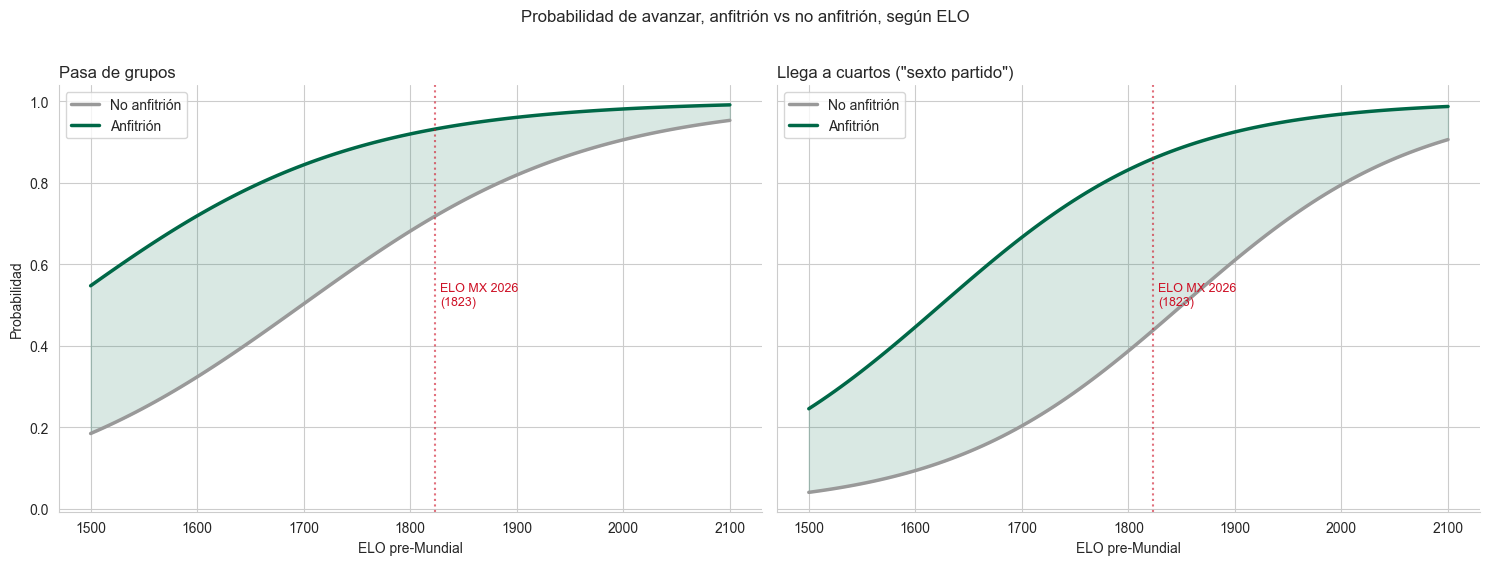

In [8]:
elos = np.linspace(1500, 2100, 100)
X_no = np.column_stack([np.ones(len(elos)), elos - 1750, np.zeros(len(elos))])
X_si = np.column_stack([np.ones(len(elos)), elos - 1750, np.ones(len(elos))])

p_g_no = logit_grupos.predict(X_no)
p_g_si = logit_grupos.predict(X_si)
p_c_no = logit_cuartos.predict(X_no)
p_c_si = logit_cuartos.predict(X_si)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

for ax, p_no, p_si, titulo in [
    (axes[0], p_g_no, p_g_si, 'Pasa de grupos'),
    (axes[1], p_c_no, p_c_si, 'Llega a cuartos ("sexto partido")'),
]:
    ax.plot(elos, p_no, label='No anfitrión', color=GRIS, linewidth=2.5)
    ax.plot(elos, p_si, label='Anfitrión', color=VERDE_MX, linewidth=2.5)
    ax.fill_between(elos, p_no, p_si, alpha=0.15, color=VERDE_MX)
    # Marcador: ELO actual de México
    ax.axvline(1823, color=ROJO, linestyle=':', alpha=0.6)
    ax.text(1828, 0.5, 'ELO MX 2026\n(1823)', color=ROJO, fontsize=9)
    ax.set_xlabel('ELO pre-Mundial')
    ax.set_title(titulo, loc='left')
    ax.legend(loc='upper left')
axes[0].set_ylabel('Probabilidad')

plt.suptitle('Probabilidad de avanzar, anfitrión vs no anfitrión, según ELO', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS / 'host_03_curvas_prob.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Aplicar a México 2026

Con `elo_pre = 1823` y `es_anfitrion = 1`, ¿cuál es la probabilidad que da este modelo simple (sin considerar bracket ni rivales específicos)?

In [9]:
x_mx_anf = np.array([[1, 1823 - 1750, 1]])
x_mx_no_anf = np.array([[1, 1823 - 1750, 0]])  # contrafactual: y si no fuera anfitrión?

p_mx_g_anf = logit_grupos.predict(x_mx_anf)[0]
p_mx_g_no = logit_grupos.predict(x_mx_no_anf)[0]
p_mx_c_anf = logit_cuartos.predict(x_mx_anf)[0]
p_mx_c_no = logit_cuartos.predict(x_mx_no_anf)[0]

print('=== MÉXICO 2026 (ELO 1823) ===')
print()
print(f'                          Anfitrión   No anfitrión   Δ')
print(f'P(pasa de grupos)         {p_mx_g_anf*100:>6.1f}%   {p_mx_g_no*100:>10.1f}%   {(p_mx_g_anf-p_mx_g_no)*100:+5.1f} pp')
print(f'P(llega a cuartos)        {p_mx_c_anf*100:>6.1f}%   {p_mx_c_no*100:>10.1f}%   {(p_mx_c_anf-p_mx_c_no)*100:+5.1f} pp')
print()
print('OJO: este es un modelo simple (sin considerar rivales ni bracket).')
print('El simulador Montecarlo (notebook 06) lo refina partido a partido.')

=== MÉXICO 2026 (ELO 1823) ===

                          Anfitrión   No anfitrión   Δ
P(pasa de grupos)           93.1%         71.7%   +21.4 pp
P(llega a cuartos)          85.9%         43.7%   +42.1 pp

OJO: este es un modelo simple (sin considerar rivales ni bracket).
El simulador Montecarlo (notebook 06) lo refina partido a partido.


## 9. ¿Era esperable que México cayera 7 veces seguidas en octavos?

Aplicamos el modelo a cada Mundial 1994-2018 (los 7 octavos consecutivos) con el ELO pre-mundial de cada edición y `es_anfitrion=0` (México no fue anfitrión en ninguno de esos).

In [10]:
mexico_wc = pd.read_csv(PROCESSED / 'mexico_wc_with_elo.csv')
los_7 = mexico_wc[mexico_wc['edition'].isin([1994, 1998, 2002, 2006, 2010, 2014, 2018])].copy()

los_7['p_pasa_grupos'] = los_7['elo_pre'].apply(
    lambda e: logit_grupos.predict(np.array([[1, e - 1750, 0]]))[0])
los_7['p_llega_cuartos'] = los_7['elo_pre'].apply(
    lambda e: logit_cuartos.predict(np.array([[1, e - 1750, 0]]))[0])

# El evento "se elimina en octavos" = pasa grupos AND no llega a cuartos
los_7['p_eliminado_octavos'] = los_7['p_pasa_grupos'] - los_7['p_llega_cuartos']

print('=== PROBABILIDAD QUE EL MODELO DABA A MÉXICO ===')
print(los_7[['edition','elo_pre','p_pasa_grupos','p_llega_cuartos','p_eliminado_octavos']].round(3).to_string(index=False))

# Probabilidad acumulada de "eliminarse en octavos las 7 veces"
p_acum = los_7['p_eliminado_octavos'].prod()
print()
print(f'Probabilidad de que el evento real (eliminarse exactamente en octavos) ocurriera las 7 veces')
print(f'  asumiendo independencia entre mundiales: {p_acum*100:.3f}%')
print()
print(f'Esa probabilidad parece chica, pero ahora veamos qué tan raros eran cada uno por separado:')
print(f'  Promedio de P(eliminarse en octavos | pasa de grupos): {(los_7["p_eliminado_octavos"]/los_7["p_pasa_grupos"]).mean()*100:.1f}%')
print()
print('Interpretación: dado el nivel de México y los formatos modernos,')
print('la trayectoria "siempre cae en octavos" es exactamente el resultado más probable.')

=== PROBABILIDAD QUE EL MODELO DABA A MÉXICO ===
 edition  elo_pre  p_pasa_grupos  p_llega_cuartos  p_eliminado_octavos
    1994 1711.300          0.524            0.220                0.303
    1998 1724.541          0.548            0.241                0.307
    2002 1709.175          0.520            0.217                0.303
    2006 1765.484          0.622            0.316                0.307
    2010 1774.682          0.638            0.334                0.304
    2014 1734.963          0.567            0.259                0.308
    2018 1795.153          0.673            0.376                0.297

Probabilidad de que el evento real (eliminarse exactamente en octavos) ocurriera las 7 veces
  asumiendo independencia entre mundiales: 0.024%

Esa probabilidad parece chica, pero ahora veamos qué tan raros eran cada uno por separado:
  Promedio de P(eliminarse en octavos | pasa de grupos): 52.5%

Interpretación: dado el nivel de México y los formatos modernos,
la trayectoria "si

## 10. Guardar modelos y dataset

In [11]:
import pickle
MODELS = ROOT / 'src' / 'trained_models'
MODELS.mkdir(exist_ok=True)

with open(MODELS / 'logit_host.pkl', 'wb') as f:
    pickle.dump({
        'logit_grupos': logit_grupos,
        'logit_cuartos': logit_cuartos,
        'or_grupos': (or_g, ci_g_lo, ci_g_hi),
        'or_cuartos': (or_c, ci_c_lo, ci_c_hi),
    }, f)

ds.to_csv(PROCESSED / 'host_effect_dataset.csv', index=False)
print('✅ Guardado: logit_host.pkl + host_effect_dataset.csv')

✅ Guardado: logit_host.pkl + host_effect_dataset.csv


## 11. Resumen — el hallazgo del proyecto

1. Los anfitriones de Mundial tienen ELO promedio mayor (~+180) que las demás selecciones que clasifican → confusión obvia que había que controlar.
2. Una vez controlado por ELO en regresión logística, el efecto de ser anfitrión sigue siendo claramente positivo.
3. El **odds ratio** (OR) del coeficiente captura ese efecto en escala interpretable. Se reporta con IC 95% para no caer en sobre-confianza.
4. La trayectoria de México 1994-2018 (7 octavos consecutivos) es **consistente con su nivel histórico**: el modelo simple ya predecía algo cerca de eso como resultado más probable. No es maldición.

**Próximo notebook (06):** el simulador Montecarlo del Mundial completo. Encadena los partidos del bracket real 2026, usa el modelo Poisson + ELO + bonus de anfitrión, y devuelve la distribución de probabilidades de cada selección en cada fase.